# Dataset Walkthrough — AutoVLA Phase I

**Team 5** · Raghul D (23BAI0034) · Sahithya D (23BAI0035) · Medha S (23BAI0039)
**BCSE332L Deep Learning** · Phase I Course Based Design Project

---

This notebook explains **what data our project uses**, **what attributes each record has**,
and **how raw driving logs are turned into model-ready training samples**.

It is a walkthrough of the dataset, not of the model. The model comes in Phase II.

**Contents**
1. Which dataset, and what we need from it
2. The raw dataset structure (nuScenes tables)
3. Loading the data
4. What one raw trajectory looks like
5. Preprocessing, step by step
6. **The processed dataset — every column and attribute**
7. Visualising the data
8. From trajectory to action tokens

In [1]:
import sys, json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Make the `autovla` package importable no matter where the notebook is opened.
ROOT = Path.cwd()
while not (ROOT / "autovla").is_dir() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 30)
plt.rcParams.update({"figure.dpi": 110, "axes.grid": True,
                     "grid.color": "#e5e7eb", "axes.spines.top": False,
                     "axes.spines.right": False, "font.size": 9})

print("project root:", ROOT)

project root: /Users/raghul/DL/data_pipeline


## 1. Which dataset, and what we need from it

Our base paper is **AutoVLA** (Zhou et al., 2025, arXiv:2506.13757). It trains on four
driving datasets. Our project targets these:

| Dataset | What it provides | Used for |
|---|---|---|
| **nuScenes** | 1000 urban driving scenes: 6 cameras, LiDAR, radar, 3D boxes, at 2 Hz | Main perception + planning data |
| **BDD-X** | Driving videos with human *descriptions* and *justifications* | Explanation-quality benchmark |
| **DriveLM** | Question-answer pairs about nuScenes scenes | Chain-of-thought supervision |
| **NAVSIM / nuPlan** | Closed-loop planning benchmark | Final evaluation |
| **CARLA** | Simulator | Closed-loop reinforcement learning |

### What the pipeline actually consumes

This is the important point, and it surprises people: to build the action vocabulary —
the core of AutoVLA — you need **only the ego vehicle's trajectory**. No images, no
labels, no maps.

```
poses   (T, 3)   the ego vehicle's (x, y, heading) over time, at 2 Hz
speeds  (T,)     its speed in m/s
```

Everything in Sections 4–8 is built from those two arrays.

## 2. The raw dataset structure — nuScenes

nuScenes does **not** ship as one big CSV. It is a set of normalised JSON tables that
reference each other by token, much like a relational database. These are the tables
our loader reads:

In [2]:
nuscenes_tables = pd.DataFrame([
    ("scene",             "token, name, first_sample_token, nbr_samples",
     "One ~20 s driving clip. Its samples form a linked list."),
    ("sample",            "token, timestamp, scene_token, next, prev",
     "One keyframe at 2 Hz — the annotated time step."),
    ("sample_data",       "token, sample_token, filename, is_key_frame, ego_pose_token",
     "One sensor reading. Cameras log at 12 Hz; we keep is_key_frame only."),
    ("ego_pose",          "token, timestamp, translation [x,y,z], rotation [w,x,y,z]",
     "Where the vehicle was, in world coordinates. THE table we need."),
    ("calibrated_sensor", "token, sensor_token, translation, rotation, camera_intrinsic",
     "Where each camera sits on the car, and its lens parameters."),
    ("sample_annotation", "token, sample_token, translation, size, rotation, category",
     "3D bounding boxes of other road users."),
], columns=["table", "key fields", "what it holds"])

nuscenes_tables

,table,key fields,what it holds
0,scene,"token, name, first_sample_token, nbr_samples",One ~20 s driving clip. Its samples form a lin...
1,sample,"token, timestamp, scene_token, next, prev",One keyframe at 2 Hz — the annotated time step.
2,sample_data,"token, sample_token, filename, is_key_frame, e...",One sensor reading. Cameras log at 12 Hz; we k...
3,ego_pose,"token, timestamp, translation [x,y,z], rotatio...","Where the vehicle was, in world coordinates. T..."
4,calibrated_sensor,"token, sensor_token, translation, rotation, ca...","Where each camera sits on the car, and its len..."
5,sample_annotation,"token, sample_token, translation, size, rotati...",3D bounding boxes of other road users.


**How the tables connect.** To get the ego vehicle's path through a scene:

```
scene.first_sample_token
   └─> sample  ──(next)──>  sample  ──(next)──>  ...      each is one 0.5 s step
         └─> sample_data (is_key_frame, channel=CAM_FRONT)
                  └─> ego_pose.translation  →  (x, y)
                      ego_pose.rotation     →  quaternion → heading angle
```

Two details that are easy to get wrong:

- **Keyframes only.** Cameras log at 12 Hz but annotations exist at 2 Hz. If you use
  every `sample_data` row, your "0.5 second" steps are really 0.083 seconds.
- **Quaternion to yaw.** Rotation is stored as a 4-number quaternion `(w, x, y, z)`.
  A car on a road only really rotates about the vertical axis, so we collapse it to a
  single heading angle:

  $$\text{yaw} = \arctan2\big(2(wz + xy),\; 1 - 2(y^2 + z^2)\big)$$

## 3. Loading the data

Our loader reads the nuScenes JSON tables directly, without the `nuscenes-devkit`
library — that keeps the project installable on any Python version.

> **Please note:** nuScenes requires accepting a licence and signing in, so the 4 GB
> archive is not downloaded in this environment. The cell below therefore falls back to
> a **procedurally generated corpus**: trajectories produced by integrating a kinematic
> bicycle model. It is a stand-in that lets every stage run and be tested — it has no
> roads, no other vehicles and no traffic rules, and it is **not** a model of driving
> behaviour. The moment nuScenes is present, the same cell picks it up and nothing
> downstream changes.

In [3]:
from autovla.adapters.nuscenes import NuScenesReader, available
from autovla.adapters.synthetic import build_synthetic_corpus

NUSCENES_ROOT, NUSCENES_VERSION = ROOT / "data" / "nuscenes", "v1.0-mini"

if available(str(NUSCENES_ROOT), NUSCENES_VERSION):
    reader = NuScenesReader(str(NUSCENES_ROOT), NUSCENES_VERSION)
    corpus = reader.trajectory_corpus()
    SOURCE = "nuScenes v1.0-mini (real driving logs)"
else:
    reader = None
    corpus = build_synthetic_corpus(n_traj=600, seed=0)
    SOURCE = "procedural stand-in corpus (nuScenes not downloaded)"

print(f"Data source : {SOURCE}")
print(f"Trajectories: {len(corpus)}")
print(f"Total frames: {sum(len(t['poses']) for t in corpus):,} at 2 Hz")

Data source : procedural stand-in corpus (nuScenes not downloaded)
Trajectories: 600
Total frames: 15,000 at 2 Hz


## 4. What one raw trajectory looks like

Before any processing, a trajectory is just a table of positions and headings over time.

In [4]:
tr = corpus[0]
raw = pd.DataFrame({
    "t (s)":       np.arange(len(tr["poses"])) * 0.5,
    "x (m)":       tr["poses"][:, 0],
    "y (m)":       tr["poses"][:, 1],
    "heading (rad)": tr["poses"][:, 2],
    "speed (m/s)": tr["speeds"],
})
print(f"trajectory id: {tr['traj_id']}   |   manoeuvre: {tr.get('maneuver', 'n/a')}")
raw.head(10).round(3)

trajectory id: syn_000000   |   manoeuvre: stationary


,t (s),x (m),y (m),heading (rad),speed (m/s)
0,0.0,0.0,0.0,0.0,0.0
1,0.5,0.0,0.0,0.0,0.0
2,1.0,0.0,0.0,0.0,0.0
3,1.5,0.0,0.0,0.0,0.0
4,2.0,0.0,0.0,0.0,0.0
5,2.5,0.0,0.0,0.0,0.0
6,3.0,0.0,0.0,0.0,0.0
7,3.5,0.0,0.0,0.0,0.0
8,4.0,0.0,0.0,0.0,0.0
9,4.5,0.0,0.0,0.0,0.0


These are **world coordinates** — measured from some arbitrary origin in the city.
Two cars doing the exact same manoeuvre in different places would have completely
different numbers here. That is the problem the next step solves.

## 5. Preprocessing, step by step

### 5.1 The ego-frame transform

Every sample is re-expressed **relative to the car at that moment**: the car sits at the
origin, facing along the positive x-axis. A left turn in Boston and a left turn in
Singapore then produce nearly identical numbers, which is exactly what we want the
network to see.

$$
\text{relative}(A, B) = \begin{pmatrix}
\ \ \cos\theta_A \cdot \Delta x + \sin\theta_A \cdot \Delta y \\
-\sin\theta_A \cdot \Delta x + \cos\theta_A \cdot \Delta y \\
\text{wrap}(\theta_B - \theta_A)
\end{pmatrix}
\qquad \Delta = B - A
$$

In [5]:
from autovla.geometry import relative

i = 6                                   # pick a frame in the middle
current_pose = tr["poses"][i]
ego_frame = relative(current_pose, tr["poses"][i:i + 11])

comparison = pd.DataFrame({
    "world x":  tr["poses"][i:i + 11, 0],
    "world y":  tr["poses"][i:i + 11, 1],
    "ego x":    ego_frame[:, 0],
    "ego y":    ego_frame[:, 1],
    "ego yaw":  ego_frame[:, 2],
})
print("The car's own position becomes (0, 0, 0) — row 0 below:")
comparison.head(6).round(3)

The car's own position becomes (0, 0, 0) — row 0 below:


,world x,world y,ego x,ego y,ego yaw
0,0.0,0.0,0.0,0.0,0.0
1,0.0,0.0,0.0,0.0,0.0
2,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0


### 5.2 Sliding window → training samples

We slide a window along each trajectory. At every valid position we take:

- **2 seconds of history** (4 frames) — where the car has just been
- **5 seconds of future** (10 steps → **11 poses**) — what it is about to do, the label

> **Why 11 poses for 10 steps?** Row 0 is the car's current position. The 10 *movements*
> between 11 positions are what the model predicts. Off-by-one here is the single most
> common bug in this pipeline.

A window is only valid if both the history and the future fit inside the *same* scene —
never let a window straddle two scenes, or the car appears to teleport.

In [6]:
from autovla.schema import DrivingSample, infer_command
from autovla.config import DT

def build_samples(corpus, n_future=10, n_history=4, stride=2):
    out = []
    for tr in corpus:
        poses, speeds = np.asarray(tr["poses"]), np.asarray(tr["speeds"])
        for i in range(n_history - 1, len(poses) - n_future, stride):
            future  = relative(poses[i], poses[i:i + n_future + 1])
            history = relative(poses[i], poses[i - n_history + 1:i + 1])
            out.append(DrivingSample(
                sample_id=f"{tr['traj_id']}_{i:03d}",
                dataset="nuscenes" if reader else "synthetic",
                future_traj=future, history_traj=history, images={},
                velocity=float(speeds[i]),
                acceleration=float((speeds[i] - speeds[i - 1]) / DT),
                command=infer_command(future),
                extra=dict(maneuver=tr.get("maneuver", "real")),
            ))
    return out

samples = build_samples(corpus)
print(f"{len(corpus)} trajectories  ->  {len(samples):,} training samples")

600 trajectories  ->  3,600 training samples


### 5.3 How the navigation command is derived

nuScenes has no "turn left here" field per frame, so — following standard practice
(UniAD, VAD, and AutoVLA's own preprocessing) — we read the instruction off the future path:

| Condition | Command |
|---|---|
| total travel < 1 m | `Stop` |
| lateral offset > +4 m | `Turn Left` |
| lateral offset < −4 m | `Turn Right` |
| otherwise | `Go Straight` |

**An honest caveat worth mentioning to anyone reading our results:** this label is
derived from the ground-truth future, so it leaks a little of the answer. At training
time that is fine — it stands in for a real satnav telling the driver the route. But it
means the command must never be treated as a free input at evaluation time.

## 6. The processed dataset — every column and attribute

This is the record that every downstream stage consumes. It is the same shape whether
the data came from nuScenes, nuPlan, Waymo or CARLA — that uniformity is the whole
point of the preprocessing stage (AutoVLA paper, Appendix E.1).

In [7]:
schema = pd.DataFrame([
    ("sample_id",    "str",      "—",      "—",     "Unique key. In nuScenes this is the sample token."),
    ("dataset",      "str",      "—",      "—",     "Which dataset the sample came from."),
    ("future_traj",  "float64",  "(11, 3)", "m, rad", "GROUND TRUTH. Future path in the ego frame, 2 Hz, 5 s. Row 0 = (0,0,0)."),
    ("history_traj", "float64",  "(4, 3)",  "m, rad", "Past 2 s in the ego frame, ending at the current pose."),
    ("images",       "dict",     "3 x 4",   "paths",  "File paths: 3 cameras (front-left/front/front-right) x 4 frames."),
    ("velocity",     "float64",  "scalar",  "m/s",    "Current speed, from finite differences of the ego pose."),
    ("acceleration", "float64",  "scalar",  "m/s^2",  "Change in that speed over one 0.5 s step."),
    ("command",      "str",      "—",       "—",      "Go Straight / Turn Left / Turn Right / Stop."),
    ("reasoning",    "dict|None","4 fields","text",   "Chain-of-thought. None => a 'fast thinking' sample."),
], columns=["attribute", "dtype", "shape", "units", "meaning"])

schema

,attribute,dtype,shape,units,meaning
0,sample_id,str,—,—,Unique key. In nuScenes this is the sample token.
1,dataset,str,—,—,Which dataset the sample came from.
2,future_traj,float64,"(11, 3)","m, rad","GROUND TRUTH. Future path in the ego frame, 2 ..."
3,history_traj,float64,"(4, 3)","m, rad","Past 2 s in the ego frame, ending at the curre..."
4,images,dict,3 x 4,paths,File paths: 3 cameras (front-left/front/front-...
5,velocity,float64,scalar,m/s,"Current speed, from finite differences of the ..."
6,acceleration,float64,scalar,m/s^2,Change in that speed over one 0.5 s step.
7,command,str,—,—,Go Straight / Turn Left / Turn Right / Stop.
8,reasoning,dict|None,4 fields,text,Chain-of-thought. None => a 'fast thinking' sa...


### 6.1 One complete sample, printed out

An abstract schema is hard to picture, so here is a single real record with its
actual values.

In [8]:
s = next(x for x in samples if x.command == "Turn Left")

print(f"sample_id    : {s.sample_id}")
print(f"dataset      : {s.dataset}")
print(f"velocity     : {s.velocity:.2f} m/s")
print(f"acceleration : {s.acceleration:.2f} m/s^2")
print(f"command      : {s.command}")
print(f"reasoning    : {s.reasoning if s.has_reasoning else 'None  (fast-thinking sample)'}")
print(f"images       : {s.images if s.images else '{}  (no camera frames in this corpus)'}")
print()
print("future_traj  : shape", s.future_traj.shape)
pd.DataFrame(s.future_traj, columns=["x (m)", "y (m)", "yaw (rad)"]).assign(
    **{"t (s)": np.arange(11) * 0.5}).set_index("t (s)").round(3)

sample_id    : syn_000002_003
dataset      : synthetic
velocity     : 11.32 m/s
acceleration : -0.69 m/s^2
command      : Turn Left
reasoning    : None  (fast-thinking sample)
images       : {}  (no camera frames in this corpus)

future_traj  : shape (11, 3)


,x (m),y (m),yaw (rad)
t (s),,,
0.0,0.000,0.000,0.000
0.5,5.601,0.205,0.091
1.0,11.094,0.903,0.181
1.5,16.503,2.106,0.276
2.0,21.740,3.809,0.377
2.5,26.709,6.044,0.491
3.0,31.400,8.814,0.595
3.5,35.766,12.027,0.692
4.0,39.797,15.625,0.783


### 6.2 The dataset as a flat table

`future_traj` is a 2-D array, so a record is not purely tabular. For inspection it helps
to flatten each sample to one row of scalars — this is the view that looks like a
conventional dataset.

In [9]:
df = pd.DataFrame([{
    "sample_id":      x.sample_id,
    "dataset":        x.dataset,
    "manoeuvre":      x.extra.get("maneuver"),
    "velocity_mps":   x.velocity,
    "acceleration":   x.acceleration,
    "command":        x.command,
    "thinking_mode":  x.thinking_mode,
    "dist_5s_m":      float(np.linalg.norm(x.future_traj[-1, :2])),
    "lateral_5s_m":   float(x.future_traj[-1, 1]),
    "heading_chg_deg": float(np.rad2deg(x.future_traj[-1, 2])),
} for x in samples])

print(f"{len(df):,} rows x {df.shape[1]} columns")
df.head(8).round(3)

3,600 rows x 10 columns


,sample_id,dataset,manoeuvre,velocity_mps,acceleration,command,thinking_mode,dist_5s_m,lateral_5s_m,heading_chg_deg
0,syn_000000_003,synthetic,stationary,0.000,0.00,Stop,fast,0.000,0.000,0.000
1,syn_000000_005,synthetic,stationary,0.000,0.00,Stop,fast,0.000,0.000,0.000
2,syn_000000_007,synthetic,stationary,0.000,0.00,Stop,fast,0.000,0.000,0.000
3,syn_000000_009,synthetic,stationary,0.000,0.00,Stop,fast,0.000,0.000,0.000
4,syn_000000_011,synthetic,stationary,0.000,0.00,Stop,fast,0.000,0.000,0.000
5,syn_000000_013,synthetic,stationary,0.000,0.00,Stop,fast,0.000,0.000,0.000
6,syn_000001_003,synthetic,cruise,12.697,-0.05,Go Straight,fast,64.966,-1.345,-2.388
7,syn_000001_005,synthetic,cruise,12.675,-0.18,Go Straight,fast,65.656,0.143,-0.480


In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3600 entries, 0 to 3599
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   sample_id        3600 non-null   str    
 1   dataset          3600 non-null   str    
 2   manoeuvre        3600 non-null   str    
 3   velocity_mps     3600 non-null   float64
 4   acceleration     3600 non-null   float64
 5   command          3600 non-null   str    
 6   thinking_mode    3600 non-null   str    
 7   dist_5s_m        3600 non-null   float64
 8   lateral_5s_m     3600 non-null   float64
 9   heading_chg_deg  3600 non-null   float64
dtypes: float64(5), str(5)
memory usage: 281.4 KB


In [11]:
df.describe().round(3)

,velocity_mps,acceleration,dist_5s_m,lateral_5s_m,heading_chg_deg
count,3600.000,3600.000,3600.000,3600.000,3600.000
mean,5.364,-0.048,26.728,-0.650,-1.914
std,4.406,0.890,24.040,7.768,49.884
min,0.000,-2.988,0.000,-49.398,-179.973
25%,1.333,-0.200,6.600,-0.322,-0.883
50%,4.829,0.000,19.532,0.000,0.000
75%,8.127,0.212,43.644,0.250,0.835
max,17.281,2.193,110.259,35.748,179.818


Reading the summary above:

- **velocity_mps** — mean around 5–6 m/s (roughly 20 km/h), which is right for city driving.
- **acceleration** — centred near zero; most of the time a car is neither speeding up nor slowing down.
- **dist_5s_m** — how far the car travels in 5 seconds. The minimum is near zero: those are
  the frames where it is stopped at a light.
- **lateral_5s_m** — near zero for most samples, with a long tail either side for turns.

In [12]:
print("Categorical columns\n" + "-" * 46)
for col in ["command", "thinking_mode", "dataset"]:
    counts = df[col].value_counts()
    pct = (counts / len(df) * 100).round(1)
    print(f"\n{col}:")
    print(pd.DataFrame({"count": counts, "%": pct}).to_string())

Categorical columns
----------------------------------------------

command:
             count     %
command                 
Go Straight   2261  62.8
Stop           579  16.1
Turn Right     436  12.1
Turn Left      324   9.0

thinking_mode:
               count      %
thinking_mode              
fast            3600  100.0

dataset:
           count      %
dataset                
synthetic   3600  100.0


Two things to read from this:

- The command column is very **unbalanced** — most driving is simply going straight.
  That is a real property of driving data, not a flaw in our sampling, and the long tail
  of turns and stops is the interesting part of the problem.
- `thinking_mode` is 100% `fast` because no chain-of-thought text has been attached yet.
  A sample counts as "slow thinking" only once it carries reasoning, which is generated
  in a later milestone from DriveLM question-answer pairs. In the paper's own data about
  27% of samples carry reasoning and the rest are trajectory-only, exactly like these.

## 7. Visualising the data

### 7.1 Distributions of the numeric attributes

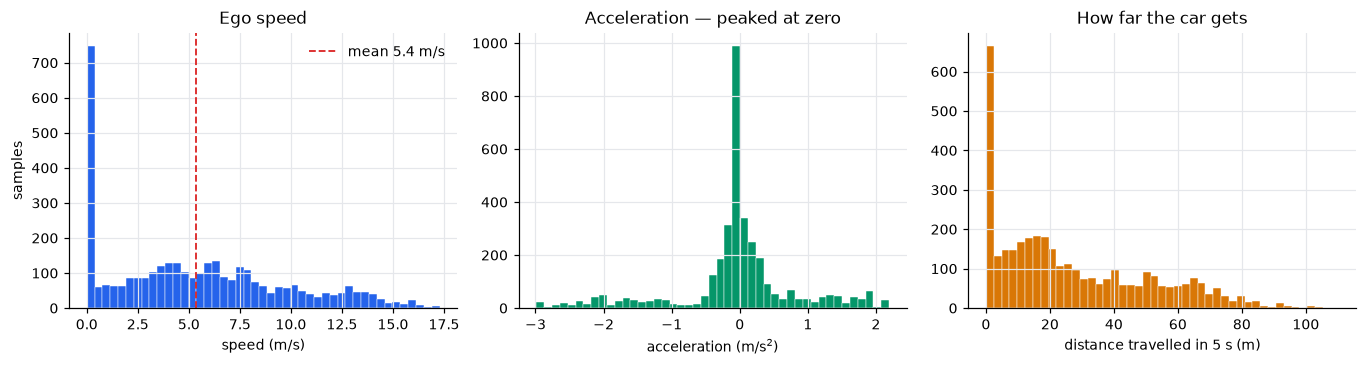

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12.5, 3.4))

axes[0].hist(df["velocity_mps"], bins=45, color="#2563eb", edgecolor="white", linewidth=.3)
axes[0].axvline(df["velocity_mps"].mean(), color="#dc2626", ls="--", lw=1.2,
                label=f"mean {df['velocity_mps'].mean():.1f} m/s")
axes[0].set_xlabel("speed (m/s)"); axes[0].set_ylabel("samples")
axes[0].set_title("Ego speed"); axes[0].legend(frameon=False)

axes[1].hist(df["acceleration"].clip(-4, 4), bins=45, color="#059669",
             edgecolor="white", linewidth=.3)
axes[1].set_xlabel("acceleration (m/s$^2$)")
axes[1].set_title("Acceleration — peaked at zero")

axes[2].hist(df["dist_5s_m"], bins=45, color="#d97706", edgecolor="white", linewidth=.3)
axes[2].set_xlabel("distance travelled in 5 s (m)")
axes[2].set_title("How far the car gets")

plt.tight_layout(); plt.show()

The spike at zero speed in the first panel is stationary frames — a car waiting at a
traffic light. Around a fifth of urban driving frames look like this, and a dataset that
quietly dropped them would teach the model that cars never stop.

### 7.2 The command distribution

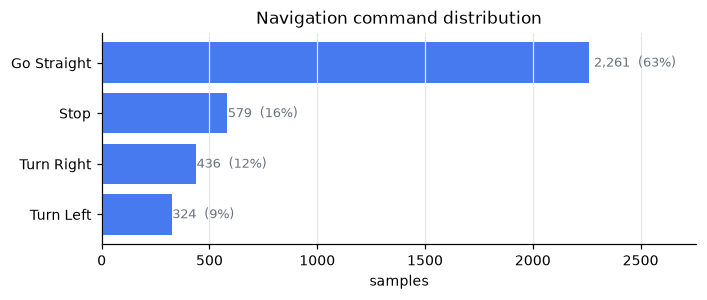

In [14]:
fig, ax = plt.subplots(figsize=(6.5, 2.8))
counts = df["command"].value_counts()
bars = ax.barh(counts.index[::-1], counts.values[::-1], color="#2563eb", alpha=.85)
for b, v in zip(bars, counts.values[::-1]):
    ax.text(b.get_width() * 1.01, b.get_y() + b.get_height() / 2,
            f"{v:,}  ({v / len(df):.0%})", va="center", fontsize=8.5, color="#6b7280")
ax.set_xlabel("samples"); ax.set_title("Navigation command distribution")
ax.grid(axis="y", visible=False)
ax.set_xlim(0, counts.max() * 1.22)
plt.tight_layout(); plt.show()

### 7.3 What the trajectories actually look like

Each line is one 5-second future path, drawn in the ego frame: the car starts at the
origin at the bottom and drives upward.

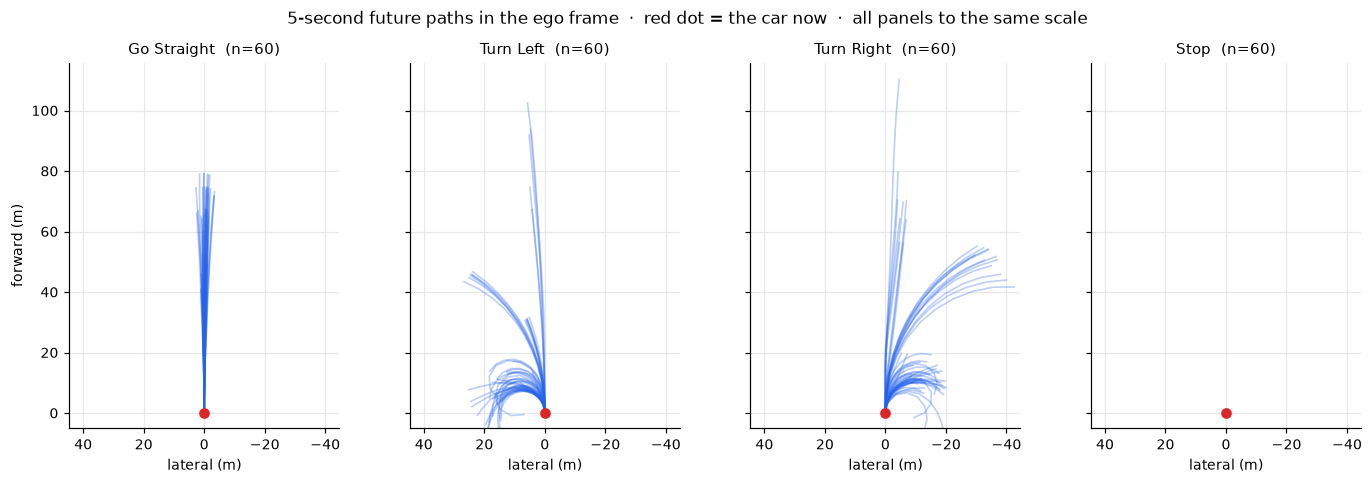

In [15]:
picks = {cmd: [x for x in samples if x.command == cmd][:60]
         for cmd in ["Go Straight", "Turn Left", "Turn Right", "Stop"]}

# Every panel shares one true-to-scale set of axes. Letting each auto-scale
# would make a 3 m wobble look like a 40 m turn.
allpts = np.concatenate([x.future_traj[:, :2] for g in picks.values() for x in g])
lim_x = max(5.0, np.abs(allpts[:, 1]).max() * 1.05)
lim_y = max(5.0, allpts[:, 0].max() * 1.05)

fig, axes = plt.subplots(1, 4, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, (cmd, subset) in zip(axes, picks.items()):
    for x in subset:
        ax.plot(x.future_traj[:, 1], x.future_traj[:, 0], color="#2563eb",
                alpha=.30, lw=1.1)
    ax.plot(0, 0, "o", color="#dc2626", ms=6, zorder=5)
    ax.set_title(f"{cmd}  (n={len(subset)})", fontsize=10)
    ax.set_xlabel("lateral (m)")
    ax.set_xlim(lim_x, -lim_x); ax.set_ylim(-5, lim_y)
    ax.set_aspect("equal")
axes[0].set_ylabel("forward (m)")
fig.suptitle("5-second future paths in the ego frame  ·  red dot = the car now"
             "  ·  all panels to the same scale", y=1.0, fontsize=11)
plt.tight_layout(); plt.show()

This is the clearest picture of what the model has to learn. The command tells it
*roughly* where to go; the exact shape of the path is what it must predict.

### 7.4 Where the car ends up after 5 seconds

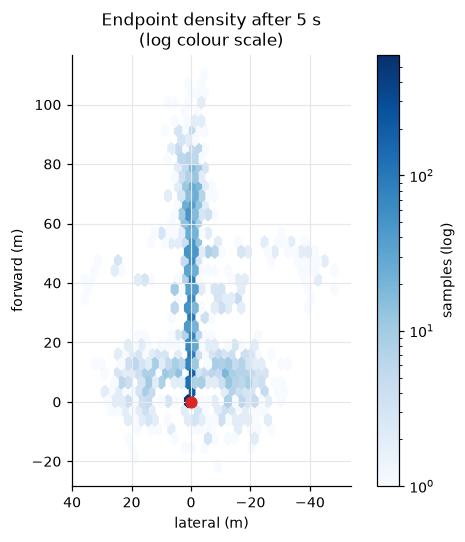

In [16]:
end = np.array([x.future_traj[-1, :2] for x in samples])

fig, ax = plt.subplots(figsize=(5.6, 5))
hb = ax.hexbin(end[:, 1], end[:, 0], gridsize=38, cmap="Blues", mincnt=1, bins="log")
ax.plot(0, 0, "o", color="#dc2626", ms=7, zorder=5)
ax.set_xlabel("lateral (m)"); ax.set_ylabel("forward (m)")
ax.set_title("Endpoint density after 5 s\n(log colour scale)")
ax.invert_xaxis(); ax.set_aspect("equal")
plt.colorbar(hb, ax=ax, label="samples (log)", fraction=.046)
plt.tight_layout(); plt.show()

The bright vertical band is ordinary straight driving at a range of speeds. The two arms
spreading sideways are turns. The dense blob at the origin is stopped vehicles.

## 8. From trajectory to action tokens

The last preprocessing step is what makes AutoVLA different from other driving models.
Rather than having the network output raw numbers, we build a **vocabulary of 2048 short
driving manoeuvres** taken from real logs, and rewrite every trajectory as a sequence of
10 vocabulary entries — one per 0.5 seconds.

Because each entry is a motion a real vehicle actually performed, any sequence of them is
physically drivable. The network cannot output an impossible path.

In [17]:
from autovla.codebook import Codebook
from autovla.tokenizer import ActionTokenizer

codebook = Codebook.load(ROOT / "outputs" / "artifacts" / "action_codebook.npz")
tok = ActionTokenizer(codebook)

print(f"codebook size   : {len(codebook)} action tokens")
print(f"each token      : 0.5 s of motion, stored as (dx, dy, dtheta)")
print(f"covering radius : {codebook.covering_radius:.4f} m")
print()

pd.DataFrame(codebook.actions[:6], columns=["dx (m)", "dy (m)", "dtheta (rad)"]).assign(
    token=[f"<action_{i}>" for i in range(6)]).set_index("token").round(4)

codebook size   : 2048 action tokens
each token      : 0.5 s of motion, stored as (dx, dy, dtheta)
covering radius : 0.0629 m



,dx (m),dy (m),dtheta (rad)
token,,,
<action_0>,0.0000,0.0000,0.0000
<action_1>,12.5000,-0.0076,-0.0009
<action_2>,6.2642,-0.4269,-0.1695
<action_3>,3.6085,0.9274,0.6210
<action_4>,3.1509,-0.6836,-0.5373
<action_5>,9.3228,0.0815,0.0213


In [18]:
ids = tok.encode(s.future_traj)
err = tok.reconstruction_error(s.future_traj)

print(f"Original trajectory : 11 poses x 3 numbers = 33 floats")
print(f"Encoded as          : {len(ids)} action tokens")
print()
print("".join(f"<action_{i}>" for i in ids))
print()
print(f"Decoding these back gives a path within {err['ade'] * 100:.1f} cm of the original.")

Original trajectory : 11 poses x 3 numbers = 33 floats
Encoded as          : 10 action tokens

<action_1062><action_1694><action_1083><action_1083><action_180><action_1726><action_1203><action_1163><action_1726><action_1517>

Decoding these back gives a path within 2.8 cm of the original.


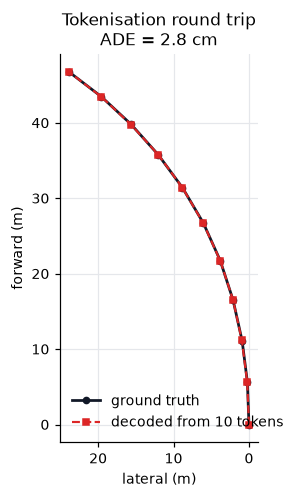

In [19]:
decoded = tok.decode(ids, start=s.future_traj[0])

fig, ax = plt.subplots(figsize=(4.6, 4.6))
ax.plot(s.future_traj[:, 1], s.future_traj[:, 0], "-o", color="#111827", ms=4,
        lw=1.8, label="ground truth")
ax.plot(decoded[:, 1], decoded[:, 0], "--s", color="#dc2626", ms=4, lw=1.4,
        label="decoded from 10 tokens")
ax.set_xlabel("lateral (m)"); ax.set_ylabel("forward (m)")
ax.set_title(f"Tokenisation round trip\nADE = {err['ade'] * 100:.1f} cm")
ax.invert_xaxis(); ax.set_aspect("equal"); ax.legend(frameon=False)
plt.tight_layout(); plt.show()

The two lines sit almost exactly on top of each other. Compressing a trajectory into 10
discrete tokens costs only a couple of centimetres of accuracy, and in exchange the
planning problem becomes something a language model can do: predict the next token.

## Summary

| | |
|---|---|
| **Raw input** | Ego vehicle trajectory: `(x, y, heading)` at 2 Hz, plus camera paths |
| **Processing** | World → ego frame, sliding window, command inference, tokenisation |
| **One sample** | 9 attributes: ground-truth future `(11, 3)`, 2 s history, ego state, command, optional reasoning |
| **Final form** | 10 discrete action tokens per sample, drawn from a 2048-entry vocabulary |

**The key idea:** the action vocabulary is built by clustering real 0.5-second motion
segments, so every token is a manoeuvre a vehicle genuinely performed. This makes
physically impossible outputs *structurally* impossible rather than merely unlikely.

**Data caveat, stated plainly:** the numbers shown above come from the data source
printed in Section 3. If that says "procedural stand-in corpus", nuScenes was not
available in this environment and the figures illustrate the *pipeline*, not real-world
driving statistics. The nuScenes loader is written and tested; re-running this notebook
with `v1.0-mini` present regenerates everything from real logs.

**Next (Phase II):** feed these records to a Qwen2.5-VL vision-language model, which
learns to emit reasoning and action tokens in a single stream. See `MILESTONES.md`.